# XGBoost Model — Campus Waste Forecasting

This notebook trains an XGBoost model for waste forecasting. XGBoost (eXtreme Gradient Boosting) is a tree-based ensemble method that excels at tabular data. Unlike Prophet and SARIMA, XGBoost requires explicit feature engineering but can capture complex non-linear relationships between features and the target variable.

## 0. Imports

All required libraries are imported here. XGBoost provides the gradient boosting implementation. Scikit-learn handles cross-validation and hyperparameter tuning.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Hyperparameters

XGBoost has many tunable parameters. Key ones include: n_estimators (number of trees), max_depth (tree complexity), learning_rate (step size), and regularization terms (reg_alpha, reg_lambda). The grid search explores combinations of these parameters.

In [2]:
# ── Forecast Settings ─────────────────────────────────────────────────────────
FORECAST_HORIZON = 7          # Days to predict ahead
TEST_DAYS = 30                # Days held out for final test evaluation
VALIDATION_SPLITS = 3         # Number of CV folds for hyperparameter tuning

# ── XGBoost Default Hyperparameters ───────────────────────────────────────────
XGBOOST_PARAMS = {
    'n_estimators': 100,       # Number of boosting rounds
    'max_depth': 6,            # Maximum tree depth (controls complexity)
    'learning_rate': 0.1,      # Step size shrinkage
    'subsample': 0.8,          # Fraction of samples per tree
    'colsample_bytree': 0.8,   # Fraction of features per tree
    'reg_alpha': 0.1,          # L1 regularization
    'reg_lambda': 1.0,         # L2 regularization
    'random_state': 42,
    'n_jobs': -1
}

# ── Grid Search Settings ──────────────────────────────────────────────────────
ENABLE_GRID_SEARCH = True      # Set to False to use default parameters
GRID_SEARCH_PARAMS = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# ── Feature Selection ─────────────────────────────────────────────────────────
# Columns to exclude from features
EXCLUDE_COLS = ['date', 'Canteen_Section', 'Waste_Weight_kg']

# ── Data Path ─────────────────────────────────────────────────────────────────
DATA_PATH = 'data/waste_features_xgb.csv'

print("Hyperparameters loaded.")
print(f"Grid search: {'Enabled' if ENABLE_GRID_SEARCH else 'Disabled'}")

Hyperparameters loaded.
Grid search: Enabled


## 2. Helper Functions

Modular functions for data preparation, model training, evaluation, and feature importance analysis.

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load the feature-engineered dataset and parse dates."""
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    return df


def prepare_features(df: pd.DataFrame, section: str = None, exclude_cols: list = None):
    """
    Prepare feature matrix X and target y.
    
    Args:
        df: Dataset with all features
        section: If provided, filter to this section only; else use all data
        exclude_cols: Columns to exclude from features
    
    Returns:
        X: Feature DataFrame
        y: Target Series
        dates: Date Series for indexing
    """
    if section:
        data = df[df['Canteen_Section'] == section].copy()
    else:
        data = df.copy()
    
    data = data.sort_values('date').reset_index(drop=True)
    
    exclude = exclude_cols or []
    feature_cols = [c for c in data.columns if c not in exclude]
    
    X = data[feature_cols]
    y = data['Waste_Weight_kg']
    dates = data['date']
    
    return X, y, dates


def temporal_split(X, y, dates, test_days: int):
    """
    Split data temporally. The most recent 'test_days' become the test set.
    
    Returns:
        X_train, X_test, y_train, y_test, train_dates, test_dates
    """
    n = len(X)
    split_idx = n - test_days
    
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    train_dates = dates.iloc[:split_idx]
    test_dates = dates.iloc[split_idx:]
    
    return X_train, X_test, y_train, y_test, train_dates, test_dates


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute evaluation metrics for regression.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def baseline_moving_average(y_train, y_test, window: int = 7) -> np.ndarray:
    """
    Compute a simple moving average baseline.
    """
    all_y = pd.concat([y_train, y_test], ignore_index=True)
    train_len = len(y_train)
    
    predictions = []
    for i in range(len(y_test)):
        idx = train_len + i
        start_idx = max(0, idx - window)
        predictions.append(all_y.iloc[start_idx:idx].mean())
    
    return np.array(predictions)


def train_xgboost_with_cv(X_train, y_train, params: dict, param_grid: dict, cv_splits: int):
    """
    Train XGBoost with time-series cross-validation and optional grid search.
    
    TimeSeriesSplit ensures training data always precedes validation data,
    preventing data leakage.
    
    Returns:
        best_model: Trained XGBRegressor with best parameters
        best_params: Dictionary of best parameters
    """
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    
    base_model = XGBRegressor(**params)
    
    if param_grid:
        print(f"Running grid search with {cv_splits}-fold time series CV...")
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"Best parameters: {best_params}")
        print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")
    else:
        print("Training with default parameters...")
        base_model.fit(X_train, y_train)
        best_model = base_model
        best_params = params
    
    return best_model, best_params


def plot_feature_importance(model, feature_names, top_n: int = 15):
    """
    Plot top N feature importances from the trained XGBoost model.
    """
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance.head(top_n)
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance


def print_metrics_comparison(baseline_metrics: dict, model_metrics: dict, model_name: str = "XGBoost"):
    """Print a formatted comparison of baseline vs model metrics."""
    print("\n" + "=" * 55)
    print(f"{'Metric':<10} {'Baseline':>12} {model_name:>12} {'Improvement':>15}")
    print("=" * 55)
    
    for metric in ['RMSE', 'MAE', 'MAPE', 'R2']:
        base_val = baseline_metrics[metric]
        model_val = model_metrics[metric]
        
        if metric == 'R2':
            improvement = model_val - base_val
            imp_str = f"+{improvement:.4f}" if improvement > 0 else f"{improvement:.4f}"
        else:
            improvement = ((base_val - model_val) / base_val) * 100 if base_val != 0 else 0
            imp_str = f"{improvement:+.1f}%"
        
        print(f"{metric:<10} {base_val:>12.4f} {model_val:>12.4f} {imp_str:>15}")
    
    print("=" * 55)

## 3. Load and Explore Data

In [4]:
df = load_data(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Sections: {sorted(df['Canteen_Section'].unique())}")
print(f"\nFeature columns ({len(df.columns) - 3} features):")
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
print(feature_cols)
df.head()

Dataset shape: (15319, 31)
Date range: 2015-01-29 to 2025-08-10
Sections: ['A', 'B', 'C', 'D']

Feature columns (28 features):
['section_code', 'Foot_Traffic', 'is_holiday', 'is_special_day', 'is_weekend', 'weekday', 'month', 'quarter', 'day_of_year', 'week_of_year', 'year', 'sin_weekday', 'cos_weekday', 'sin_month', 'cos_month', 'sin_doy', 'cos_doy', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_max_7', 'section_B', 'section_C', 'section_D']


,date,Canteen_Section,section_code,Waste_Weight_kg,Foot_Traffic,is_holiday,is_special_day,is_weekend,weekday,month,...,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_max_7,section_B,section_C,section_D
0,2015-01-29,A,0,10.76,104.0,0,0,0,3,1,...,8.79,7.85,5.06,14.680000,13.712143,5.848741,24.92,False,False,False
1,2015-01-30,A,0,14.24,97.5,0,0,0,4,1,...,24.92,22.49,8.20,14.961429,13.920000,5.558274,24.92,False,False,False
2,2015-01-31,A,0,18.52,68.0,0,1,1,5,1,...,12.58,9.37,18.35,13.435714,13.330714,3.425862,19.96,False,False,False
3,2015-02-01,A,0,6.50,70.0,0,1,1,6,2,...,9.73,5.62,3.72,14.284286,13.984286,3.883649,19.96,False,False,False
4,2015-02-02,A,0,20.55,194.4,0,0,0,0,2,...,19.96,18.45,22.08,13.822857,14.047143,4.634284,19.96,False,False,False


## 4. Train and Evaluate XGBoost (All Sections)

We train separate XGBoost models for each canteen section. This allows each model to learn section-specific patterns. The training uses time-series cross-validation to ensure temporal integrity.

In [5]:
sections = sorted(df['Canteen_Section'].unique())
results = {}

for section in sections:
    print(f"\n{'='*60}")
    print(f"SECTION {section}")
    print(f"{'='*60}")
    
    # Prepare features
    X, y, dates = prepare_features(df, section, EXCLUDE_COLS)
    print(f"Total observations: {len(X)}, Features: {X.shape[1]}")
    
    # Temporal split
    X_train, X_test, y_train, y_test, train_dates, test_dates = temporal_split(
        X, y, dates, TEST_DAYS
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")
    
    # Baseline
    baseline_pred = baseline_moving_average(y_train, y_test, window=7)
    baseline_metrics = compute_metrics(y_test.values, baseline_pred)
    print(f"\nBaseline (7-day MA): RMSE={baseline_metrics['RMSE']:.4f}")
    
    # Train XGBoost
    param_grid = GRID_SEARCH_PARAMS if ENABLE_GRID_SEARCH else None
    model, best_params = train_xgboost_with_cv(
        X_train, y_train, XGBOOST_PARAMS, param_grid, VALIDATION_SPLITS
    )
    
    # Predict on test set
    xgb_pred = model.predict(X_test)
    
    # Evaluate
    xgb_metrics = compute_metrics(y_test.values, xgb_pred)
    
    print_metrics_comparison(baseline_metrics, xgb_metrics, "XGBoost")
    
    # Store results
    results[section] = {
        'model': model,
        'best_params': best_params,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'test_dates': test_dates,
        'predictions': xgb_pred,
        'baseline_pred': baseline_pred,
        'baseline_metrics': baseline_metrics,
        'xgb_metrics': xgb_metrics,
        'feature_names': list(X.columns)
    }


SECTION A
Total observations: 3820, Features: 28
Train: 3790 | Test: 30

Baseline (7-day MA): RMSE=7.5522
Running grid search with 3-fold time series CV...
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV RMSE: 5.2033

Metric         Baseline      XGBoost     Improvement
RMSE             7.5522       6.1093          +19.1%
MAE              6.5191       4.5975          +29.5%
MAPE            84.8682      43.7047          +48.5%
R2              -0.2586       0.1764         +0.4350

SECTION B
Total observations: 3831, Features: 28
Train: 3801 | Test: 30

Baseline (7-day MA): RMSE=6.7115
Running grid search with 3-fold time series CV...
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE: 5.2760

Metric         Baseline      XGBoost     Improvement
RMSE             6.7115       5.8471          +12.9%
MAE              5.3409      

## 5. Feature Importance Analysis

XGBoost provides feature importance scores based on how often features are used in splits and their contribution to reducing error. This helps understand which factors most influence waste generation.


Section A - Top 15 Features:


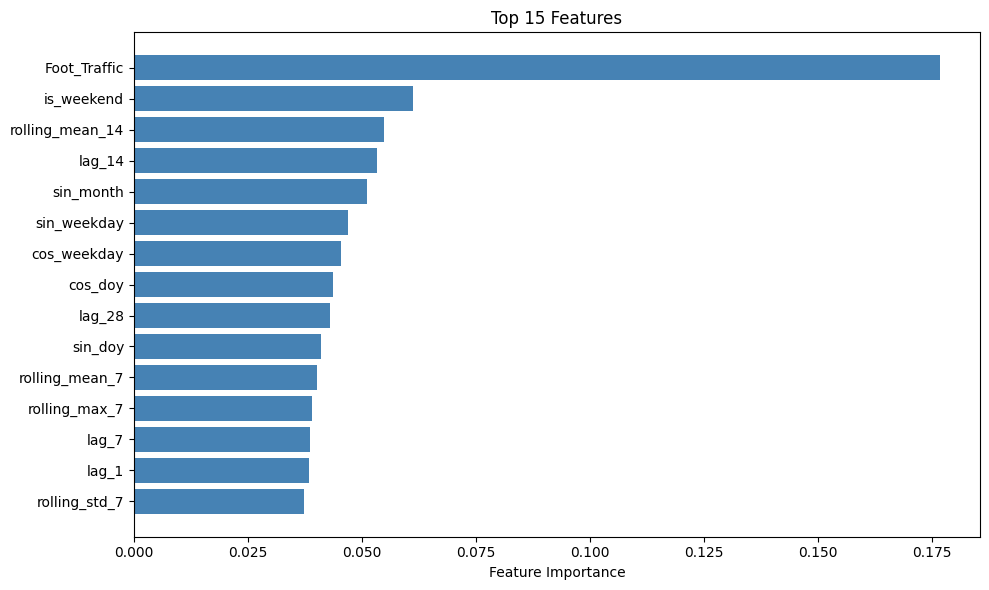


Section B - Top 15 Features:


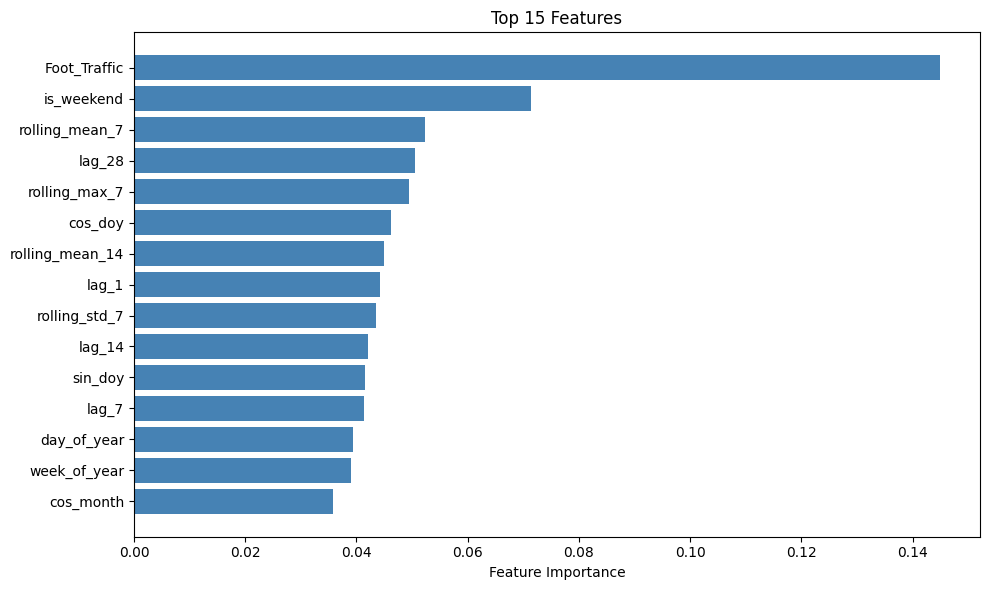


Section C - Top 15 Features:


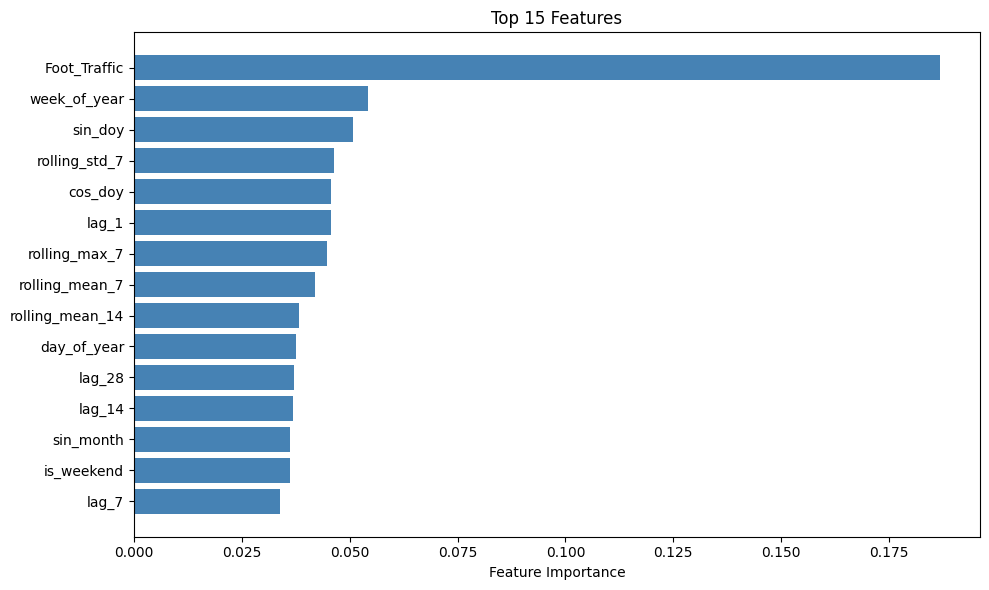


Section D - Top 15 Features:


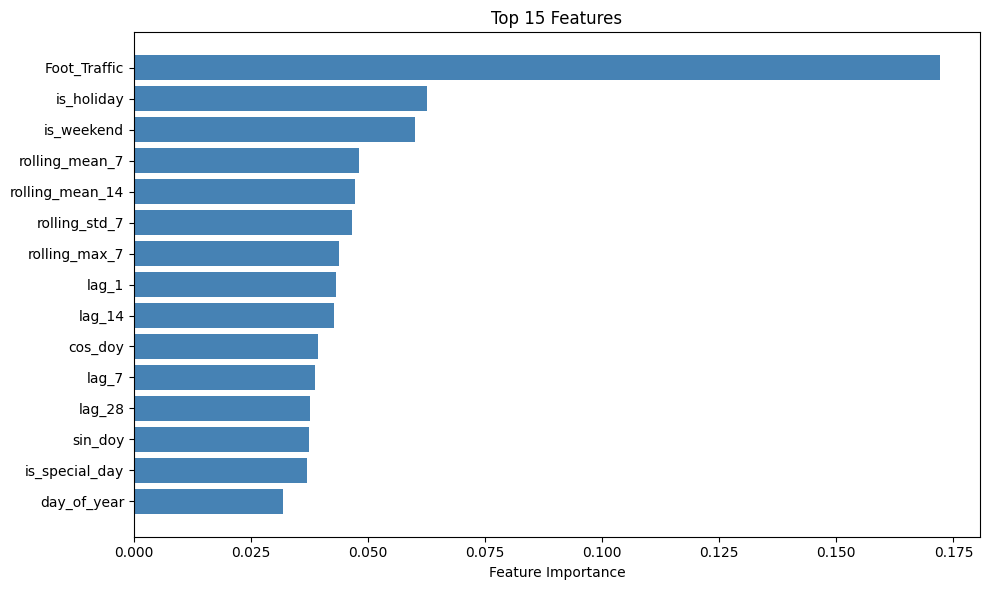

In [6]:
# Feature importance for each section
for section in sections:
    print(f"\nSection {section} - Top 15 Features:")
    res = results[section]
    importance_df = plot_feature_importance(res['model'], res['feature_names'], top_n=15)

## 6. Visualize Forecasts

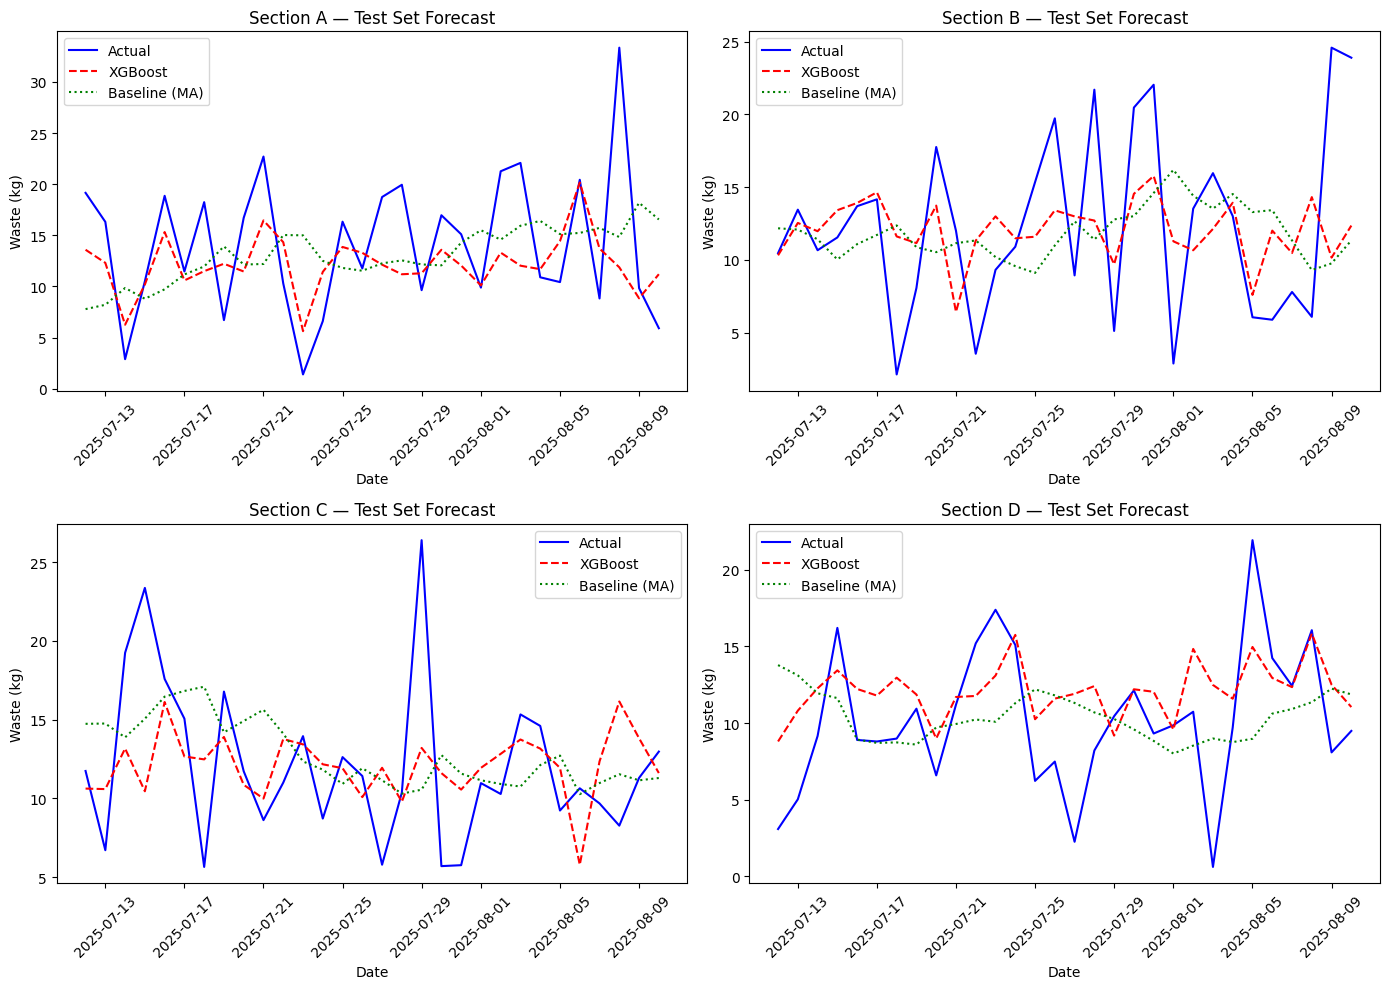

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, section in enumerate(sections):
    ax = axes[idx]
    res = results[section]
    
    test_dates = res['test_dates']
    actual = res['y_test'].values
    
    ax.plot(test_dates, actual, 'b-', label='Actual', linewidth=1.5)
    ax.plot(test_dates, res['predictions'], 'r--', label='XGBoost', linewidth=1.5)
    ax.plot(test_dates, res['baseline_pred'], 'g:', label='Baseline (MA)', linewidth=1.5)
    
    ax.set_title(f"Section {section} — Test Set Forecast")
    ax.set_xlabel('Date')
    ax.set_ylabel('Waste (kg)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Seven-Day Ahead Forecast

For XGBoost, multi-step forecasting requires recursive prediction: predict day 1, then use that prediction as lag_1 for day 2, and so on. This section demonstrates the recursive approach.

In [8]:
def forecast_7_days_xgboost(model, last_row: pd.Series, feature_names: list, 
                            df_section: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a 7-day ahead forecast using recursive prediction.
    
    For each day:
    1. Update lag features using previous predictions
    2. Update calendar features for the new date
    3. Predict waste for that day
    
    Args:
        model: Trained XGBoost model
        last_row: Last row of features from training data
        feature_names: List of feature column names
        df_section: Original section data for computing rolling features
    
    Returns:
        DataFrame with date and predicted waste
    """
    predictions = []
    current_features = last_row.copy()
    last_date = df_section['date'].max()
    
    # Get recent history for rolling calculations
    recent_waste = list(df_section['Waste_Weight_kg'].tail(28).values)
    
    for day in range(1, 8):
        future_date = last_date + pd.Timedelta(days=day)
        
        # Update calendar features
        current_features['weekday'] = future_date.dayofweek
        current_features['month'] = future_date.month
        current_features['quarter'] = future_date.quarter
        current_features['day_of_year'] = future_date.dayofyear
        current_features['week_of_year'] = future_date.isocalendar().week
        current_features['year'] = future_date.year
        
        # Update cyclical features
        current_features['sin_weekday'] = np.sin(2 * np.pi * future_date.dayofweek / 7)
        current_features['cos_weekday'] = np.cos(2 * np.pi * future_date.dayofweek / 7)
        current_features['sin_month'] = np.sin(2 * np.pi * future_date.month / 12)
        current_features['cos_month'] = np.cos(2 * np.pi * future_date.month / 12)
        current_features['sin_doy'] = np.sin(2 * np.pi * future_date.dayofyear / 365)
        current_features['cos_doy'] = np.cos(2 * np.pi * future_date.dayofyear / 365)
        
        # Update lag features (use predictions for recent days)
        if 'lag_1' in feature_names:
            current_features['lag_1'] = recent_waste[-1]
        if 'lag_7' in feature_names:
            current_features['lag_7'] = recent_waste[-7] if len(recent_waste) >= 7 else recent_waste[0]
        if 'lag_14' in feature_names:
            current_features['lag_14'] = recent_waste[-14] if len(recent_waste) >= 14 else recent_waste[0]
        if 'lag_28' in feature_names:
            current_features['lag_28'] = recent_waste[-28] if len(recent_waste) >= 28 else recent_waste[0]
        
        # Update rolling features
        if 'rolling_mean_7' in feature_names:
            current_features['rolling_mean_7'] = np.mean(recent_waste[-7:])
        if 'rolling_mean_14' in feature_names:
            current_features['rolling_mean_14'] = np.mean(recent_waste[-14:])
        if 'rolling_std_7' in feature_names:
            current_features['rolling_std_7'] = np.std(recent_waste[-7:])
        if 'rolling_max_7' in feature_names:
            current_features['rolling_max_7'] = np.max(recent_waste[-7:])
        
        # Assume normal day for future (can be adjusted)
        current_features['is_holiday'] = 0
        current_features['is_special_day'] = 1 if future_date.dayofweek >= 5 else 0
        current_features['is_weekend'] = 1 if future_date.dayofweek >= 5 else 0
        
        # Predict
        X_pred = pd.DataFrame([current_features[feature_names]])
        pred = model.predict(X_pred)[0]
        pred = max(0, pred)  # Ensure non-negative
        
        predictions.append({
            'date': future_date,
            'predicted_waste_kg': pred
        })
        
        # Update recent waste for next iteration
        recent_waste.append(pred)
    
    return pd.DataFrame(predictions)

In [9]:
print("7-Day Ahead Forecast (from last date in data)")
print("=" * 70)

forecasts_7day = {}

for section in sections:
    res = results[section]
    
    # Get section data
    section_df = df[df['Canteen_Section'] == section].sort_values('date')
    
    # Get last row of features
    last_row = res['X_test'].iloc[-1].copy()
    
    forecast_df = forecast_7_days_xgboost(
        res['model'], last_row, res['feature_names'], section_df
    )
    forecasts_7day[section] = forecast_df
    
    print(f"\nSection {section}:")
    print(forecast_df.to_string(index=False))

7-Day Ahead Forecast (from last date in data)

Section A:
      date  predicted_waste_kg
2025-08-11           12.178702
2025-08-12           12.349561
2025-08-13           12.183139
2025-08-14           12.423967
2025-08-15           11.747481
2025-08-16           12.079524
2025-08-17           12.320452

Section B:
      date  predicted_waste_kg
2025-08-11           12.469940
2025-08-12           11.704151
2025-08-13           11.587539
2025-08-14           11.608342
2025-08-15           11.203879
2025-08-16           11.506824
2025-08-17           11.477748

Section C:
      date  predicted_waste_kg
2025-08-11           11.941943
2025-08-12           11.960652
2025-08-13           11.987862
2025-08-14           11.992033
2025-08-15           11.889051
2025-08-16           11.656535
2025-08-17           11.656535

Section D:
      date  predicted_waste_kg
2025-08-11            9.713817
2025-08-12            8.919207
2025-08-13            8.972364
2025-08-14            8.955262
2025-08

## 8. Results Summary

In [10]:
print("\n" + "=" * 80)
print("OVERALL RESULTS SUMMARY")
print("=" * 80)

summary_data = []
for section in sections:
    res = results[section]
    summary_data.append({
        'Section': section,
        'Baseline_RMSE': res['baseline_metrics']['RMSE'],
        'XGBoost_RMSE': res['xgb_metrics']['RMSE'],
        'Baseline_MAE': res['baseline_metrics']['MAE'],
        'XGBoost_MAE': res['xgb_metrics']['MAE'],
        'Baseline_R2': res['baseline_metrics']['R2'],
        'XGBoost_R2': res['xgb_metrics']['R2'],
        'RMSE_Improvement_%': ((res['baseline_metrics']['RMSE'] - res['xgb_metrics']['RMSE']) / 
                               res['baseline_metrics']['RMSE'] * 100)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(4).to_string(index=False))

print(f"\nAverage RMSE Improvement: {summary_df['RMSE_Improvement_%'].mean():.2f}%")
print(f"Average XGBoost R2: {summary_df['XGBoost_R2'].mean():.4f}")


OVERALL RESULTS SUMMARY
Section  Baseline_RMSE  XGBoost_RMSE  Baseline_MAE  XGBoost_MAE  Baseline_R2  XGBoost_R2  RMSE_Improvement_%
      A         7.5522        6.1093        6.5191       4.5975      -0.2586      0.1764             19.1059
      B         6.7115        5.8471        5.3409       4.6558      -0.1659      0.1151             12.8798
      C         5.2145        4.8223        3.8029       3.5904      -0.1331      0.0310              7.5211
      D         5.0809        4.2541        3.9016       3.2857      -0.2488      0.1246             16.2733

Average RMSE Improvement: 13.95%
Average XGBoost R2: 0.1117


## 9. Save Model

In [11]:
import pickle

os.makedirs('models', exist_ok=True)

for section in sections:
    model_path = f'models/xgboost_section_{section}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'model': results[section]['model'],
            'best_params': results[section]['best_params'],
            'feature_names': results[section]['feature_names']
        }, f)
    print(f"Saved: {model_path}")

print("\nAll XGBoost models saved.")

Saved: models/xgboost_section_A.pkl
Saved: models/xgboost_section_B.pkl
Saved: models/xgboost_section_C.pkl
Saved: models/xgboost_section_D.pkl

All XGBoost models saved.
